## The 2D Ising Model Near Criticality

We study the two–dimensional Ising model on a square lattice close to its critical temperature.
The main goal is to compare two Monte Carlo update schemes:

- Metropolis (local single–spin flips)
- Swendsen–Wang (non–local cluster flips)

Both algorithms sample the same equilibrium distribution, so time-averaged observables agree.
The relevant difference is how fast the Markov chain decorrelates, especially near the critical point,
where local updates suffer from critical slowing down.

In this notebook we will:
1. define the model and observables,
2. implement both update algorithms,
3. compare them by time series, snapshots, and (most importantly) autocorrelation times.

In [76]:
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

## The 2D Ising Model

We consider spins $\sigma_i \in \{-1,+1\}$ on a $L_x\times L_y$ square lattice with periodic boundary conditions.

The Hamiltonian is
$$
H(\sigma) = -J\sum_{\langle ij\rangle}\sigma_i\sigma_j - h\sum_i\sigma_i,
$$
and the Boltzmann weight is
$$
P(\sigma)\propto e^{-\beta H(\sigma)}, \qquad \beta=\frac{1}{T}.
$$

For the 2D Ising model at $h=0$ the critical temperature is known exactly:
$$
T_c = \frac{2}{\ln(1+\sqrt{2})}\approx 2.269.
$$

Close to $T_c$ the correlation length becomes large and local updates decorrelate slowly.
Cluster updates are designed to reduce this effect.
___

## Lattice geometry and lookup tables

We consider a square lattice of size $L_x\times L_y$ with periodic boundary conditions.  
Sites are labeled by a single index
$$
n(x,y)=xL_y+y,\qquad N=L_xL_y,
$$
so the spin configuration (the Monte Carlo state) is stored as a 1D array $\sigma\in\{-1,+1\}^N$.

To avoid recomputing neighbor indices during the simulation, we precompute two *static* geometry tables:

- Neighbor table `nbrs` of shape $(N,4)$: for each site $n$, `nbrs[n] = (right, left, down, up)`.  
  This is the “hopping table” used for fast local $\Delta E$ in Metropolis.

- Bond list `bonds` of shape $(2N,2)$: an edge list of nearest-neighbor pairs $(i,j)$, storing each undirected bond once (right + down).  

  This is convenient for sums over $\langle ij\rangle$ and for Swendsen–Wang bond activation on edges.

In [77]:
def build_bonds(Lx, Ly):
    N = Lx * Ly
    bonds = np.empty((2*N, 2), dtype=np.int32)
    k = 0
    for x in range(Lx):
        for y in range(Ly):
            n = x*Ly + y 
            bonds[k] = (n, x * Ly + ((y + 1) % Ly)); k += 1
            bonds[k] = (n, ((x + 1) % Lx) * Ly + y); k += 1
    return bonds

def build_neighbours(Lx: int, Ly: int) -> np.ndarray:
    N = Lx * Ly
    nbrs = np.empty((N, 4), dtype=np.int32)
    for x in range(Lx):
        for y in range(Ly):
            n = x * Ly + y
            nbrs[n, 0] = x * Ly + ((y + 1) % Ly)  # right
            nbrs[n, 1] = x * Ly + ((y - 1) % Ly)  # left
            nbrs[n, 2] = ((x + 1) % Lx) * Ly + y  # down
            nbrs[n, 3] = ((x - 1) % Lx) * Ly + y  # up
    return nbrs

## Observables

We measure energy and magnetization of a configuration.

Using the bond list `bonds` (each undirected bond once), we compute
$$
E(\sigma) = -J\sum_{(i,j)\in\texttt{bonds}}\sigma_i\sigma_j - h\sum_i\sigma_i.
$$

We use the energy density
$$
e = \frac{E}{N},
$$
and magnetization density
$$
m = \frac{1}{N}\sum_i\sigma_i,\qquad |m|.
$$

At $h=0$ and finite $N$, symmetry implies $\langle m\rangle \approx 0$ even below $T_c$,
so $\langle |m|\rangle$ is the more robust indicator of ordering.

Later we also compute response functions from time series:
$$
\chi = \beta\left(\langle M^2\rangle-\langle M\rangle^2\right),
\qquad
C_V = \beta^2\left(\langle E^2\rangle-\langle E\rangle^2\right),
$$
and, for algorithmic comparison, the autocorrelation function and $\tau_{\mathrm{int}}$.

In [78]:
def measure(spins: np.ndarray, bonds: np.ndarray, J: float = 1.0, h: float = 0.0) -> dict:
    i = bonds[:, 0]
    j = bonds[:, 1]

    M = float(spins.sum())
    E = float(-J * np.sum(spins[i] * spins[j]) - h * M)

    N = spins.size
    m = M / N

    return {
        "E": E,
        "E2": E * E,
        "E_density": E / N,
        "M": M,
        "M2": M * M,
        "m": m,
        "abs_m": abs(m),
    }

## Utility functions (initial states + visualization)

Before implementing the Monte Carlo updates, we define a few small helpers:

- spin initialization,
- reshaping from 1D to 2D for plotting,
- compact snapshot plotting

In [ ]:
def init_spins(N: int, rng: np.random.Generator, init: str = "random") -> np.ndarray:
    if init == "random":
        return rng.choice([-1, 1], size=N).astype(np.int8)
    if init == "ordered_plus":
        return np.ones(N, dtype=np.int8)
    if init == "ordered_minus":
        return -np.ones(N, dtype=np.int8)
    raise ValueError("init must be 'random', 'ordered_plus', or 'ordered_minus'")

def spins_to_2d(spins: np.ndarray, Lx: int, Ly: int) -> np.ndarray:
    return spins.reshape(Lx, Ly)

def plot_snapshots(snaps: list[np.ndarray], titles: list[str], Lx: int, Ly: int, suptitle: str = "") -> None:
    n = len(snaps)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, sp, title in zip(axes, snaps, titles):
        ax.imshow(spins_to_2d(sp, Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    if suptitle:
        fig.suptitle(suptitle)
    plt.show()
    
def plot_run_snapshots(run: dict, Lx: int, Ly: int, which: str = "init_therm", max_panels: int = 6) -> None:
    if not run.get("snapshots", None):
        raise ValueError("Run has no snapshots. Call run_sw(..., snapshots=True).")

    if which == "init_therm":
        snaps = [run["snapshots"]["init"], run["snapshots"]["after_therm"]]
        titles = ["init", "after therm"]
        plot_snapshots(snaps, titles, Lx, Ly, suptitle=f"{run['algo']}: init → therm (T={run['T']}, h={run.get('h',0.0)})")
        return

    if which == "meas":
        items = sorted(run.get("meas_snapshots", {}).items(), key=lambda x: x[0])[:max_panels]
        snaps = [sp for _, sp in items]
        titles = [f"t={t}" for t, _ in items]
        plot_snapshots(snaps, titles, Lx, Ly, suptitle=f"{run['algo']}: meas snapshots (T={run['T']}, h={run.get('h',0.0)})")
        return

    raise ValueError("which must be 'init_therm' or 'meas'")

## Metropolis Monte Carlo (local update)

A Metropolis step proposes a local flip $\sigma_i \to -\sigma_i$.

For a site $i$, the energy change is
$$
\Delta E = 2\sigma_i\left(J\sum_{j\in nn(i)}\sigma_j + h\right).
$$

The proposal is accepted with probability
$$
P_{\mathrm{acc}}=\min\left(1, e^{-\beta \Delta E}\right).
$$

We define one Metropolis sweep as $N=L_xL_y$ such proposals.
This is a natural Monte Carlo time unit because, on average, each site is updated once per sweep.

In [80]:
def metropolis_sweep(spins: np.ndarray, nbrs: np.ndarray, beta: float, rng: np.random.Generator,
                     J: float = 1.0, h: float = 0.0) -> float:
    N = spins.size
    acc = 0

    for n in rng.permutation(N):
        s = spins[n]
        nn_sum = spins[nbrs[n]].sum()
        dE = 2.0 * s * (J * nn_sum + h)

        if dE <= 0.0 or rng.random() < np.exp(-beta * dE):
            spins[n] = -s
            acc += 1

    return acc / N

def run_metropolis(
    T: float, bonds: np.ndarray, nbrs: np.ndarray,
    n_therm: int, n_meas: int,
    init: str = "random", seed: int = 0,
    J: float = 1.0, h: float = 0.0, kB: float = 1.0,
    snapshot_at: tuple[int, ...] = (),
) -> dict:
    rng = np.random.default_rng(seed)
    beta = 1.0 / (kB * T)
    N = nbrs.shape[0]

    spins = init_spins(N, rng, init=init)

    snaps = {"init": spins.copy()}

    # thermalization
    for _ in range(n_therm):
        metropolis_sweep(spins, nbrs, beta, rng, J=J, h=h)
    snaps["after_therm"] = spins.copy()

    # measurement
    E = np.empty(n_meas)
    m = np.empty(n_meas)
    abs_m = np.empty(n_meas)
    acc = np.empty(n_meas)

    meas_snaps = {}
    snap_set = set(snapshot_at)

    for t in range(n_meas):
        acc[t] = metropolis_sweep(spins, nbrs, beta, rng, J=J, h=h)

        obs = measure(spins, bonds, J=J, h=h)
        E[t] = obs["E_density"]
        m[t] = obs["m"]
        abs_m[t] = obs["abs_m"]

        if t in snap_set:
            meas_snaps[t] = spins.copy()

    return {
        "algo": "metropolis",
        "T": float(T),
        "beta": float(beta),
        "init": init,
        "E": E,
        "m": m,
        "abs_m": abs_m,
        "acc": acc,
        "time_unit": "sweep",
        "snapshots": snaps,
        "meas_snapshots": meas_snaps,
    }

## A single representative sanity run (low T vs high T)

We do one low-temperature and one high-temperature run:

- $T=1.5$ (ordered phase): $|m|$ close to 1, very low acceptance.
- $T=3.5$ (disordered phase): $|m|$ small, acceptance much higher.

This is not the "final physics"; it is a diagnostic that the code behaves sensibly

T=1.50  <E/N>=-1.952  <|m|>= 0.987  <acc>= 0.013


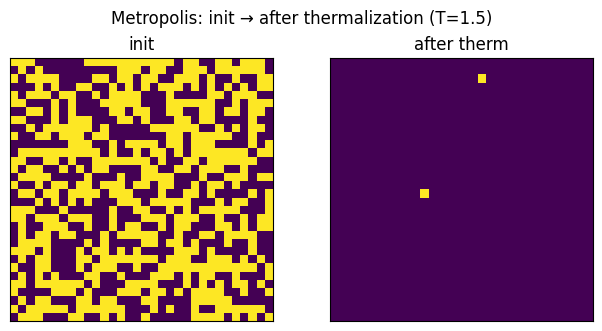

T=3.50  <E/N>=-0.658  <|m|>= 0.064  <acc>= 0.549


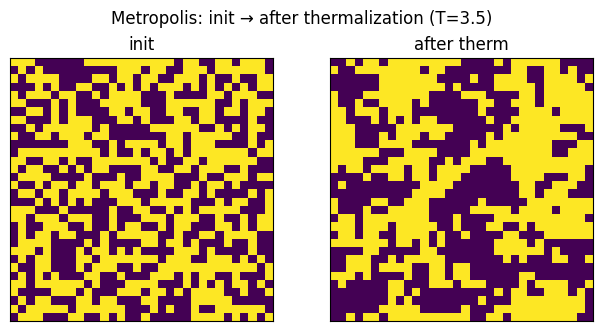

In [84]:
Lx = 32
Ly = 32
bonds = build_bonds(Lx, Ly)
nbrs  = build_neighbours(Lx, Ly)

for T in (1.5, 3.5):
    met = run_metropolis(
        T, bonds, nbrs,
        n_therm=2000, n_meas=2000,
        init="random", seed=0,
        snapshot_at=(0, 200, 800, 1999),
    )
    print(f"T={T:.2f}  <E/N>={met['E'].mean(): .3f}  <|m|>={met['abs_m'].mean(): .3f}  <acc>={met['acc'].mean(): .3f}")

    plot_snapshots(
        [met["snapshots"]["init"], met["snapshots"]["after_therm"]],
        ["init", "after therm"],
        Lx, Ly,
        suptitle=f"Metropolis: init → after thermalization (T={T})",
    )

## Swendsen–Wang algorithm and the ghost-spin construction

The Swendsen–Wang (SW) algorithm is based on the Fortuin–Kasteleyn (FK) representation
of the Ising model.  
Instead of directly sampling spin configurations, one introduces auxiliary bond variables
that encode correlations between parallel spins.

For nearest neighbours $(i,j)$ we activate a bond with probability

$$
p_{\mathrm{nn}} = 1 - e^{-2\beta J},
$$

but only if $\sigma_i = \sigma_j$.
The activated bonds define a graph on the lattice.
Its connected components are clusters, and each cluster is flipped as a whole.

This construction satisfies detailed balance because
the joint spin–bond distribution reproduces the Boltzmann weight after summing over bonds.
Cluster flips then correspond to symmetry operations of this joint measure.

---

### Why the ghost spin is needed for $h \neq 0$

At zero field, the Hamiltonian is invariant under the global symmetry

$$
\sigma_i \rightarrow -\sigma_i.
$$

Therefore flipping a cluster with probability $1/2$ preserves detailed balance.

For $h \neq 0$ this symmetry is broken:
$
H(\sigma) \neq H(-\sigma),
$
so naive cluster flips would bias the sampling.

The ghost-spin trick restores the FK structure in the presence of a field:

- introduce one additional node $g$,
- connect spins aligned with the field to $g$ with probability

$$
p_{\mathrm{g}} = 1 - e^{-2\beta |h|}.
$$

Clusters connected to the ghost node represent spins energetically favored by the field.
They are not flipped.
All other clusters are flipped with probability $1/2$.

This construction reproduces the correct Boltzmann weight including the term
$-h\sum_i \sigma_i$ and therefore preserves detailed balance.

In [82]:
def sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=0.0, return_details=False):
    N = spins.size
    p_nn = 1.0 - np.exp(-2.0 * beta * J)

    i = bonds[:, 0]
    j = bonds[:, 1]

    parallel = (spins[i] == spins[j])
    active_nn = parallel & (rng.random(size=bonds.shape[0]) < p_nn)

    # ghost bonds
    if h == 0.0:
        active_g = np.zeros(N, dtype=bool)
        p_g = 0.0
        align = np.zeros(N, dtype=bool)
    else:
        p_g = 1.0 - np.exp(-2.0 * beta * abs(h))
        sgn = 1 if h > 0 else -1
        align = (spins == sgn)
        active_g = align & (rng.random(size=N) < p_g)

    # Build sparse adjacency for graph with N+1 nodes (ghost at index N)
    # edges from lattice
    rows = i[active_nn]
    cols = j[active_nn]
    data = np.ones(rows.size, dtype=np.int8)

    # edges to ghost
    if active_g.any():
        gi = np.nonzero(active_g)[0]
        rows = np.concatenate([rows, gi])
        cols = np.concatenate([cols, np.full(gi.size, N, dtype=np.int32)])
        data = np.concatenate([data, np.ones(gi.size, dtype=np.int8)])

    A = csr_matrix((data, (rows, cols)), shape=(N + 1, N + 1))
    A = A + A.T  # undirected graph

    n_comp, labels = connected_components(A, directed=False)

    ghost_label = labels[N]  # component id of ghost node

    # decide flips per component
    flip_comp = rng.random(n_comp) < 0.5
    flip_comp[ghost_label] = False  # clusters connected to ghost are pinned

    spins_new = spins.copy()
    spins_new[flip_comp[labels[:N]]] *= -1  # ignore label of ghost itself

    if return_details:
        return spins_new, {
            "p_nn": float(p_nn),
            "p_g": float(p_g),
            "n_comp": int(n_comp),
            "ghost_label": int(ghost_label),
            "active_nn": active_nn,
            "active_g": active_g,
            "labels": labels,  # includes ghost node at the end
        }

    return spins_new


def run_sw(
    T, bonds,
    n_therm=500, n_meas=2000,
    init="random", seed=0,
    J=1.0, h=0.0, kB=1.0,
    cluster_stats=False,
    snapshots=False,
    snapshot_at=(0, 50, 200, 999),
    overlay_step: int | None = None,
):
    rng = np.random.default_rng(seed)
    beta = 1.0 / (kB * T)
    N = bonds.max() + 1

    spins = init_spins(N, rng, init=init)

    out = {
        "algo": "sw",
        "T": float(T),
        "beta": float(beta),
        "init": init,
        "h": float(h),
        "time_unit": "cluster_step",
    }

    if snapshots:
        out["snapshots"] = {"init": spins.copy()}
        out["meas_snapshots"] = {}

    # thermalization
    for _ in range(n_therm):
        spins = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h)

    if snapshots:
        out["snapshots"]["after_therm"] = spins.copy()

    # measurement arrays
    E = np.empty(n_meas)
    m = np.empty(n_meas)
    abs_m = np.empty(n_meas)

    if cluster_stats:
        n_clusters = np.empty(n_meas, dtype=int)
        smax = np.empty(n_meas, dtype=int)

    snap_set = set(snapshot_at)

    for t in range(n_meas):
        need_details = cluster_stats or (overlay_step is not None and t == overlay_step)

        if need_details:
            spins, info = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h, return_details=True)

            if cluster_stats:
                labels_phys = info["labels"][:N]
                n_clusters[t] = np.unique(labels_phys).size
                sizes = np.bincount(labels_phys, minlength=info["n_comp"])
                smax[t] = int(sizes.max())

            # store overlay data once (only NN bonds + ghost-sites mask)
            if overlay_step is not None and t == overlay_step:
                out["overlay"] = {
                    "t": int(t),
                    "spins": spins.copy(),          # after this SW update
                    "active_nn": info["active_nn"].copy(),
                    "active_g": info["active_g"].copy(),
                }

        else:
            spins = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h)

        obs = measure(spins, bonds, J=J, h=h)
        E[t] = obs["E_density"]
        m[t] = obs["m"]
        abs_m[t] = obs["abs_m"]

        if snapshots and (t in snap_set):
            out["meas_snapshots"][t] = spins.copy()

    out["E"] = E
    out["m"] = m
    out["abs_m"] = abs_m

    if cluster_stats:
        out["n_clusters"] = n_clusters
        out["max_cluster"] = smax

    return out

## What to expect physically

- Low temperature ($T < T_c$)
  Large correlated domains form.
  SW typically builds a system-spanning cluster.
  At $h=0$ the magnetization frequently changes sign because whole domains flip.
  At $h \neq 0$ the field pins the dominant cluster.

- Near $T_c$
  Correlation length becomes large.
  SW forms broad cluster-size distributions and dramatically reduces critical slowing down.

- High temperature ($T > T_c$) 
  Only small clusters appear.
  SW effectively reduces to many small flips and behaves similarly to a local update.

h=+0.00  <m>=-0.000  <|m|>= 0.708


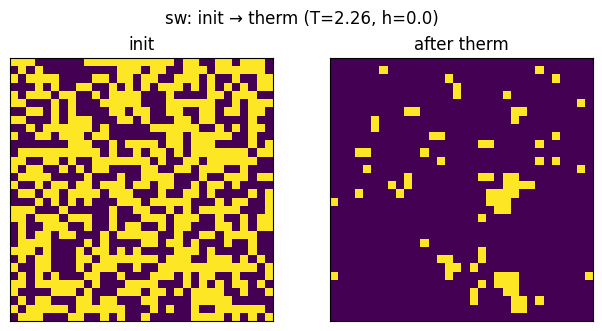

h=+0.05  <m>= 0.824  <|m|>= 0.824


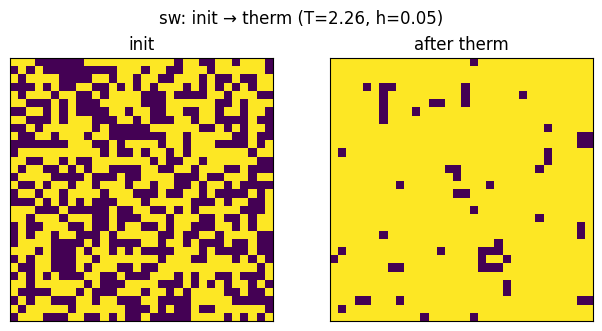

In [87]:
Lx = 32
Ly = 32
bonds = build_bonds(Lx, Ly)

T = 2.26

# 1) h=0
run0 = run_sw(T, bonds, n_therm=500, n_meas=600, seed=0, h=0.0, cluster_stats=True, snapshots=True, overlay_step=50)
print(f"h=+0.00  <m>={run0['m'].mean(): .3f}  <|m|>={run0['abs_m'].mean(): .3f}")
plot_run_snapshots(run0, Lx, Ly, which="init_therm")

# 2) small field
runh = run_sw(T, bonds, n_therm=500, n_meas=600, seed=0, h=0.05, cluster_stats=True, snapshots=True, overlay_step=50)
print(f"h=+0.05  <m>={runh['m'].mean(): .3f}  <|m|>={runh['abs_m'].mean(): .3f}")
plot_run_snapshots(runh, Lx, Ly, which="init_therm")

 ### Cluster visualization near $T_c$

 One Swendsen–Wang step consists of activating FK bonds between parallel spins.
 The connected components of the activated-bond graph define the clusters.

 Below we show (i) the activated bonds overlay (one SW step) and
 (ii) the resulting cluster labels (each cluster in a different color).

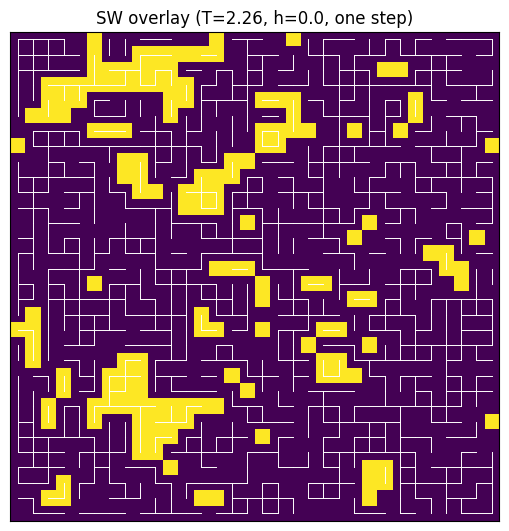

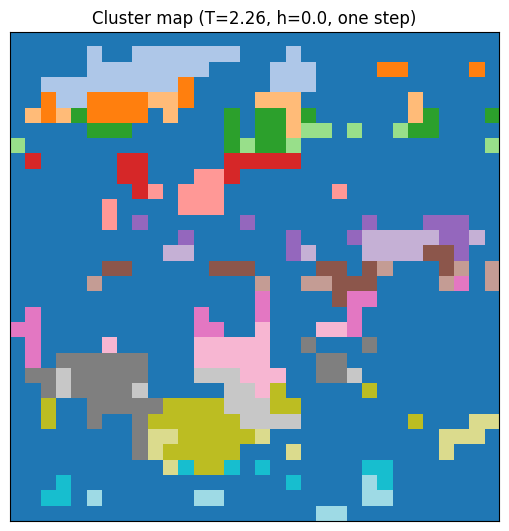

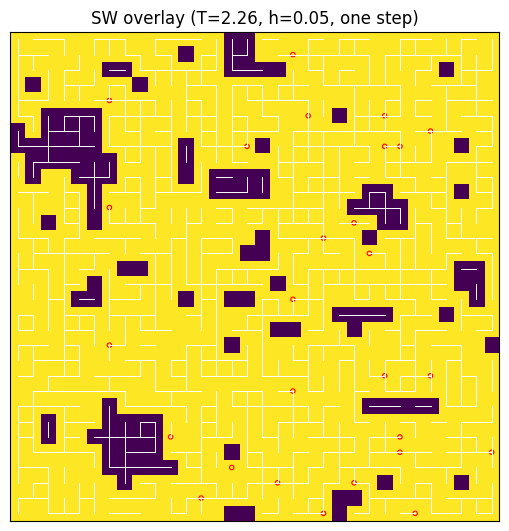

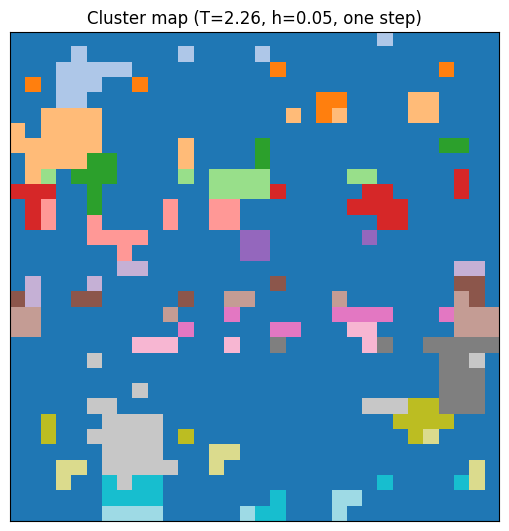

In [88]:
def plot_sw_bonds_overlay(
    spins: np.ndarray,
    Lx: int,
    Ly: int,
    bonds: np.ndarray,
    active_nn: np.ndarray,
    active_g: np.ndarray | None = None,
    title: str = "SW bond overlay (one step)",
    max_lines: int = 5000,
) -> None:

    fig, ax = plt.subplots(figsize=(5.2, 5.2), constrained_layout=True)
    ax.imshow(spins.reshape(Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

    count = 0
    for (a, b), on in zip(bonds, active_nn):
        if not on:
            continue

        xa, ya = divmod(int(a), Ly)
        xb, yb = divmod(int(b), Ly)

        # skip periodic wrap bonds for cleaner plot
        if abs(xa - xb) > 1 or abs(ya - yb) > 1:
            continue

        ax.plot([ya, yb], [xa, xb], linewidth=0.7, color="w")
        count += 1
        if count >= max_lines:
            break

    # mark ghost-connected sites (if provided)
    if active_g is not None and np.any(active_g):
        gi = np.where(active_g)[0]
        gx = gi // Ly
        gy = gi % Ly
        ax.scatter(gy, gx, s=10, marker="o", facecolors="none", edgecolors="r", linewidths=0.8)

    plt.show()


def plot_cluster_map(
    labels: np.ndarray,
    Lx: int,
    Ly: int,
    title: str = "Cluster labels (connected components)",
) -> None:
    
    fig, ax = plt.subplots(figsize=(5.2, 5.2), constrained_layout=True)
    ax.imshow(labels.reshape(Lx, Ly), interpolation="nearest", cmap="tab20")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    plt.show()

# one illustrative example near Tc
Lx = 32
Ly = 32
bonds = build_bonds(Lx, Ly)

T = 2.26
rng = np.random.default_rng(0)
beta = 1.0 / T

spins = init_spins(Lx * Ly, rng, init="random")

for h in (0.0, 0.05):
    # thermalize a bit (keep short for a demo)
    for _ in range(200):
        spins = sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=h)

    # take ONE SW step with details
    spins_new, info = sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=h, return_details=True)

    # overlay shows bonds built on "spins" (pre-flip)
    plot_sw_bonds_overlay(
        spins=spins,
        Lx=Lx, Ly=Ly,
        bonds=bonds,
        active_nn=info["active_nn"],
        active_g=info["active_g"] if h != 0.0 else None,
        title=f"SW overlay (T={T}, h={h}, one step)",
    )

    # cluster map: use component labels of PHYSICAL sites (exclude ghost node)
    labels_phys = info["labels"][:Lx * Ly]
    plot_cluster_map(
        labels=labels_phys,
        Lx=Lx, Ly=Ly,
        title=f"Cluster map (T={T}, h={h}, one step)",
    )